<a href="https://colab.research.google.com/github/hnermin1990/Cohort-Project/blob/main/cohort_analiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cohort Analysis — Tələbə layihəsi

Bu layihədə `sales.csv` datasından istifadə edərək aylıq və həftəlik `cohort analysis` aparacayıq. Analiz zamanı `cohort`, `lifetime`, `retention`, `churn`, `revenue` və `ARPU` anlayışlarından istifadə ediləcək.


## 1. Data Overview və Data Cleaning

### Task 1. Data Overview

Layihəyə lazım olan kitabxanaları import edərək başadım, `sales.csv` faylını yüklədim və datasetlə ümumi tanışlıq apardım.

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
sales=pd.read_csv("/content/drive/MyDrive/projects (1)/projects/cohort analysis 1/sales.csv")

/tmp/ipykernel_3698/1188113482.py:1: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.



In [ ]:
sales.head()

,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,Customer Since,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name
0,100354678,01-10-2020,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
1,100354678,01-10-2020,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
2,100354680,01-10-2020,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
3,100354680,01-10-2020,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
4,100367357,13-11-2020,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus


In [ ]:
sales.shape

(286392, 33)

In [ ]:
sales.nunique()

,0
order_id,201716
order_date,365
status,13
item_id,286392
sku,47932
qty_ordered,72
price,7561
discount_amount,14577
category,15
payment_method,13


* Dataset 286392 sətirdən, 33 sütundan ibarətdir.
* nunique() vasitəsilə müəyyən etdm ki, datasetdə 64248 unikal müştəri, 201716 unikal sifariş mövcuddur.





### Task 2. Data Cleaning



In [ ]:
orders=sales[["order_id","order_date","cust_id","full_name","status","qty_ordered","price","discount_amount","payment_method","year","month"]].copy()
orders.sample(5)

,order_id,order_date,cust_id,full_name,status,qty_ordered,price,discount_amount,payment_method,year,month
76971,100387939,20-12-2020,13340,"Diggins, Collin",complete,5,20.0,23.74194,Easypay,2020,Dec-20
266661,100535757,29-06-2021,109760,"Norberg, Phillis",canceled,2,125.0,18.75000,Easypay_MA,2021,Jun-21
92830,100386403,20-12-2020,19312,"Tietjen, Marva",complete,2,1108.2,173.82000,Easypay_MA,2020,Dec-20
204617,100540507,11-07-2021,8378,"Fruge, Prince",canceled,9,79.5,0.00000,Easypay,2021,Jul-21
257962,100526549,13-06-2021,107934,"Hose, Abe",received,1,2437.5,0.00000,bankalfalah,2021,Jun-21


* Datasetdə bəzi sütunlar analiz zamanı bizə lazım olmayacaq. İstifadə edəcəyimiz sütunları saxlayaraq yeni `orders `cədvəli yaratdım.
* copy() burada Pandasa bildirir ki, `orders` artıq `sales`-dən müstəqil DataFrame-dir.




In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         286392 non-null  object 
 1   order_date       286392 non-null  object 
 2   cust_id          286392 non-null  int64  
 3   full_name        286392 non-null  object 
 4   status           286392 non-null  object 
 5   qty_ordered      286392 non-null  int64  
 6   price            286392 non-null  float64
 7   discount_amount  286392 non-null  float64
 8   payment_method   286392 non-null  object 
 9   year             286392 non-null  int64  
 10  month            286392 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 24.0+ MB


In [ ]:
orders["order_date"].isna().sum()

np.int64(0)

In [ ]:
orders['order_date'] = pd.to_datetime(orders['order_date'], dayfirst=True, errors='coerce')

In [ ]:
orders

,order_id,order_date,cust_id,full_name,status,qty_ordered,price,discount_amount,payment_method,year,month
0,100354678,2020-10-01,60124,"Titus, Jani",received,21,89.9,0.0,cod,2020,Oct-20
1,100354678,2020-10-01,60124,"Titus, Jani",received,11,19.0,0.0,cod,2020,Oct-20
2,100354680,2020-10-01,60124,"Titus, Jani",complete,9,149.9,0.0,cod,2020,Oct-20
3,100354680,2020-10-01,60124,"Titus, Jani",complete,9,79.9,0.0,cod,2020,Oct-20
4,100367357,2020-11-13,60124,"Titus, Jani",received,2,99.9,0.0,cod,2020,Nov-20
...,...,...,...,...,...,...,...,...,...,...,...
286387,100562365,2021-09-30,115323,"Latham, Brady",paid,2,4419.9,0.0,Easypay,2021,Sep-21
286388,100562376,2021-09-30,115324,"Brunetti, Bennie",cod,2,39.9,0.0,cod,2021,Sep-21
286389,100562383,2021-09-30,115325,"Giusti, Francesca",cod,2,40.0,0.0,cod,2021,Sep-21
286390,100562384,2021-09-30,115325,"Giusti, Francesca",cod,2,49.9,0.0,cod,2021,Sep-21


In [ ]:
orders.isna().mean()*100

,0
order_id,0.0
order_date,0.0
cust_id,0.0
full_name,0.0
status,0.0
qty_ordered,0.0
price,0.0
discount_amount,0.0
payment_method,0.0
year,0.0


In [ ]:
orders.shape

(286392, 11)

In [ ]:
print(orders.duplicated().sum())

11188


In [ ]:
orders=orders.drop_duplicates()

In [ ]:
orders.shape

(275204, 11)

* orders cədvəlində Missing value faizi göstərilib, duplicate sətirlər silinib.


In [ ]:
orders['status'].value_counts()

,count
status,
canceled,108689
complete,85735
received,48916
order_refunded,24709
refund,3500
cod,2612
paid,713
closed,168
payment_review,55


In [ ]:
valid_statuses = ["complete", "received", "paid", "cod"]
orders = orders[orders["status"].isin(valid_statuses)].copy()

In [ ]:
orders.shape

(137976, 11)

* "Datasetdə 12 fərqli status mövcuddur. canceled (39%) və refund/order_refunded (10%) statuslu sifarişlər faktiki satış təmsil etmədiyi üçün analizdən çıxarıldı. Yalnız complete, received, paid və cod statuslu sifarişlər 'uğurlu alış' kimi qəbul edildi, bu da orijinal datanın təxminən 50%-ni təşkil edir."

### Task 3. Revenue



In [ ]:
orders["revenue"]=(orders["price"]*orders["qty_ordered"])-orders["discount_amount"]
orders.head()

,order_id,order_date,cust_id,full_name,status,qty_ordered,price,discount_amount,payment_method,year,month,revenue
0,100354678,2020-10-01,60124,"Titus, Jani",received,21,89.9,0.0,cod,2020,Oct-20,1887.9
1,100354678,2020-10-01,60124,"Titus, Jani",received,11,19.0,0.0,cod,2020,Oct-20,209.0
2,100354680,2020-10-01,60124,"Titus, Jani",complete,9,149.9,0.0,cod,2020,Oct-20,1349.1
3,100354680,2020-10-01,60124,"Titus, Jani",complete,9,79.9,0.0,cod,2020,Oct-20,719.1
4,100367357,2020-11-13,60124,"Titus, Jani",received,2,99.9,0.0,cod,2020,Nov-20,199.8


In [ ]:
orders=orders.drop(columns=["price", "qty_ordered","discount_amount"])

* `qty_ordered`, `price` və `discount_amount` sütunlarından istifadə edərək revenue sütunu yaratdım. Daha sonra bu sütunları artıq istifadə etməyəcəyimə görə sildim.

## 2. Aylıq cohort analysis

### Task 4. First order date

Hər sifarişçinin ilk sifariş tarixini hesabladım və bu məlumatı əsas `orders` dataframe-inə əlavə etdim. Bunun üçün orders cədvəlində customer_id və order_date sütunlarına görə qruplaşdırma aparıb minimal dəyəri müəyyən etdim.

In [ ]:
first_order_date_by_customers = orders.groupby('cust_id')['order_date'].min()
first_order_date_by_customers.name = 'first_order_date'
first_order_date_by_customers.head()

,first_order_date
cust_id,
4,2020-12-06
15,2020-10-08
20,2021-03-20
21,2021-02-03
23,2021-02-23


In [ ]:
orders = orders.merge(first_order_date_by_customers,on="cust_id",how="left")

In [ ]:
orders.head()

,order_id,order_date,cust_id,full_name,status,payment_method,year,month,revenue,first_order_date
0,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,1887.9,2020-10-01
1,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,209.0,2020-10-01
2,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,1349.1,2020-10-01
3,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,719.1,2020-10-01
4,100367357,2020-11-13,60124,"Titus, Jani",received,cod,2020,Nov-20,199.8,2020-10-01


* Yaratdığım yeni ilk sifariş tarixi sütununu əsas `orders` dataframe-ə əlavə etmək üçün `orders `və `first_order_date_by_customers` cədvəllərini `cust_id` sütununa görə merge etdim.

### Task 5. Aylıq period-lar



In [ ]:
orders['first_order_month'] = orders['first_order_date'].dt.to_period('M')
orders['order_month'] = orders['order_date'].dt.to_period('M')
orders.head()

,order_id,order_date,cust_id,full_name,status,payment_method,year,month,revenue,first_order_date,first_order_month,order_month
0,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,1887.9,2020-10-01,2020-10,2020-10
1,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,209.0,2020-10-01,2020-10,2020-10
2,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,1349.1,2020-10-01,2020-10,2020-10
3,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,719.1,2020-10-01,2020-10,2020-10
4,100367357,2020-11-13,60124,"Titus, Jani",received,cod,2020,Nov-20,199.8,2020-10-01,2020-10,2020-11


In [ ]:
orders["first_order_month"].nunique()

12

* first_order_date sütununa görə ilk sifariş ayını, order_date sütununa görə sifariş ayını tapıb cədvələ əlavə etdim.
* İlk sifariş ayının unikal sayı 12-dir. Deməli 12 cohortumuz var.

### Task 6. Cohort summary


In [ ]:
cohort_grouped = orders.groupby('first_order_month').agg(
    {'order_id': 'nunique', 'cust_id': 'nunique', 'revenue': 'sum'}
).rename(columns={"order_id": "uni_num_order", "cust_id": "uni_num_customer"}).reset_index().sort_values("first_order_month")
cohort_grouped


,first_order_month,uni_num_order,uni_num_customer,revenue
0,2020-10,7915,1861,1.177076e+07
1,2020-11,8247,2555,1.292207e+07
2,2020-12,35260,14129,7.318225e+07
3,2021-01,4108,2361,3.670979e+06
4,2021-02,3273,1407,2.432889e+06
5,2021-03,8369,4174,2.024015e+07
6,2021-04,12141,6986,2.202381e+07
7,2021-05,3271,2306,3.120014e+06
8,2021-06,5756,2847,1.264487e+07
9,2021-07,2145,1435,4.459323e+06


*
Hər aylıq cohort üzrə unique order, unique customer və total revenue göstəricilərini hesabladım. Nəticəni tarix ardıcıllığı ilə təqdim etdim.

Əsas müşahidələr

1. Dekabr 2020 — kəskin anomaliya
2020-12-də sifariş sayı (34,731) əvvəlki aya (2020-11: 3,689) nisbətən ~9.4 dəfə, müştəri sayı (13,904) isə ~9.1 dəfə artıb, revenue isə 74.1M-a çatıb — bu, bütün datasetdəki ən yüksək göstəricidir və digər aylardan 10-20 dəfə fərqlənir. Bu, əksər ehtimalla bir kampaniya/endirim dövrü (Black Friday, il sonu satışı və ya böyük marketinq kampaniyası) ilə bağlı ola bilər.
* Bunu yoxlamaq üçün 2020-dekabr ayının göstəricilərinə ayrıca nəzər salaq.


In [ ]:
dec_2020 = orders[orders['order_month'] == '2020-12']

In [ ]:
dec_2020.groupby('order_date').size()

,0
order_date,
2020-12-01,92
2020-12-02,122
2020-12-03,127
2020-12-04,138
2020-12-05,236
2020-12-06,561
2020-12-07,204
2020-12-08,83
2020-12-09,126


* Görünür ki, dekabr ayının 20-30 arası sifariş sayında ciddi artım var. Bu il sonu kampaniyası və ya bayram alış-veriş tələbatı ilə bağlı ola bilər.

### Task 7. Cohort summary visualization

Aylıq cohort-lar üzrə order, customer və revenue göstəricilərini uyğun qrafiklərlə vizuallaşdırdım.

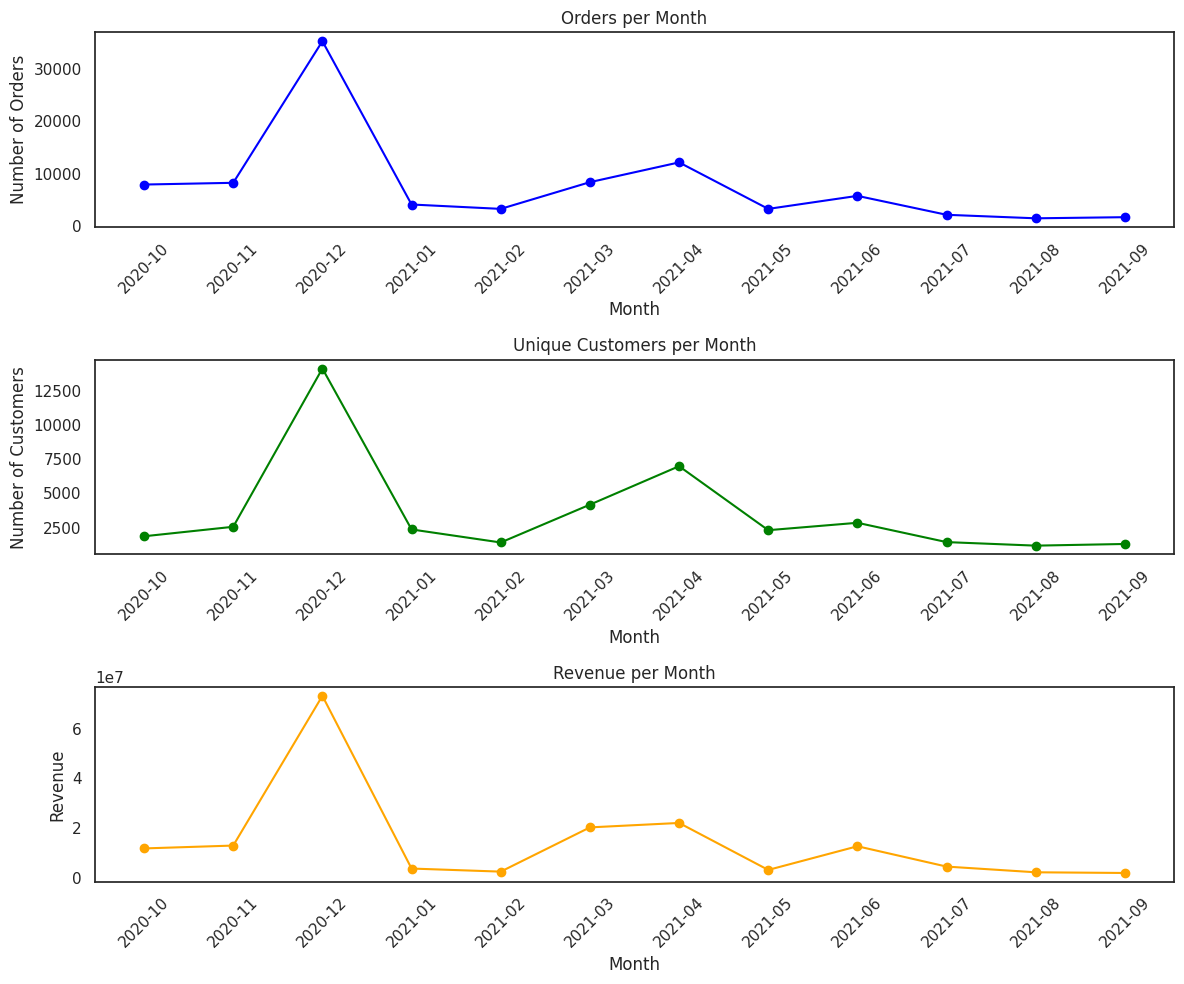

In [ ]:
cohort_grouped['first_order_month'] = cohort_grouped['first_order_month'].astype(str)
plt.figure(figsize=(12, 10))

# Plot 1: Orders
plt.subplot(3, 1, 1)
plt.plot(cohort_grouped['first_order_month'], cohort_grouped['uni_num_order'], marker='o', color='blue')
plt.title('Orders per Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# Plot 2: Customers
plt.subplot(3, 1, 2)
plt.plot(cohort_grouped['first_order_month'], cohort_grouped['uni_num_customer'], marker='o', color='green')
plt.title('Unique Customers per Month')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

# Plot 3: Revenue
plt.subplot(3, 1, 3)
plt.plot(cohort_grouped['first_order_month'], cohort_grouped['revenue'], marker='o', color='orange')
plt.title('Revenue per Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

# Adjust layout and display
plt.tight_layout()
plt.show()

* Yuxarıdakı müşahidələrim burada da özünü göstərir. Qrafiklərin pik həddi 2020-12 tarixinə aiddir. Əlavə olaraq 2021-ci ilin fevral-may ayları arasında da nisbətən artım müşahidə olunur.


### 2020-ci ilin sonunda olan sifariş artımının 2021-ci ilin sonunda niyə olmadığını araşdıraq.

In [ ]:
dec_2021=orders[orders['order_month'] == '2021-12']
dec_2021.groupby('order_date').size()

,0
order_date,


* 2021-12 tarixinin datasını nəzərdən keçirərək gördüm ki, dekabr ayı üçün ancaq ayın 9-a qədər olan məlumatlar verilmişdir. Satış həcmi ayın axırına doğru artım göstərdiyinə görə dekabr ayı üçün düzgün analiz aparmaq mümkün deyil.

### Task 8. Customer activity pivot table

Sifarişçilərin sonrakı aylarda alış aktivliyini göstərən pivot table qurdum.

In [ ]:
customer_pivot = orders.pivot_table(
    index="first_order_month",
    columns="order_month",
    values="cust_id",
    aggfunc="nunique",
    fill_value=0
)
customer_pivot

order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
first_order_month,,,,,,,,,,,,
2020-10,1861,313,387,170,123,176,151,89,142,85,54,94
2020-11,0,2555,578,219,140,206,183,109,191,85,48,92
2020-12,0,0,14129,1021,459,632,681,329,562,262,170,270
2021-01,0,0,0,2361,158,110,111,69,77,63,42,53
2021-02,0,0,0,0,1407,122,95,54,55,33,27,30
2021-03,0,0,0,0,0,4174,524,131,233,83,49,83
2021-04,0,0,0,0,0,0,6986,258,264,95,63,78
2021-05,0,0,0,0,0,0,0,2306,161,89,49,45
2021-06,0,0,0,0,0,0,0,0,2847,145,66,101


* Pivot table-da diaqonaldan aşağı hissə həmişə 0-dır, çünki müştəri öz ilk ayından əvvəl sifariş verə bilməz.
* Kohortların ilk alış ayı ən yüksək göstəriciyə malikdir. sonrakı aylarda təkrar sifariş sayı azalır.

### Task 9. Aylıq cohort metric-ləri

Datanı ilk sifariş ayı və sifariş ayı üzrə qruplaşdıraraq hər qrup üçün total revenue hesabladım.

In [ ]:
orders.pivot_table(
    index='first_order_month',
    columns='order_month',
    values='revenue',
    aggfunc='sum',
)


order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
first_order_month,,,,,,,,,,,,
2020-10,2.245335e+06,9.744598e+05,3.664542e+06,4.041428e+05,2.868095e+05,1.542769e+06,1.189060e+06,211560.808,6.004091e+05,185864.025,91358.963,374446.057
2020-11,NaN,4.518482e+06,3.636292e+06,4.411111e+05,3.205690e+05,1.328042e+06,1.037970e+06,237137.927,7.897240e+05,200361.323,76215.163,336163.712
2020-12,NaN,NaN,5.712024e+07,1.322086e+06,9.182933e+05,5.154104e+06,4.330335e+06,564636.204,2.505552e+06,351419.715,188368.315,727223.111
2021-01,NaN,NaN,NaN,2.557663e+06,1.616200e+05,1.830826e+05,2.475302e+05,132418.081,1.308464e+05,161845.465,44062.375,51911.278
2021-02,NaN,NaN,NaN,NaN,1.323578e+06,3.563382e+05,2.266897e+05,122471.828,1.846984e+05,87849.845,53731.780,77530.495
2021-03,NaN,NaN,NaN,NaN,NaN,1.465219e+07,3.182178e+06,332245.849,1.430213e+06,175456.180,55167.570,412694.829
2021-04,NaN,NaN,NaN,NaN,NaN,NaN,1.951342e+07,333437.359,1.561674e+06,153997.223,88291.610,372987.426
2021-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2365645.147,4.838156e+05,152890.558,55003.213,62659.698
2021-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.072108e+07,814671.092,610643.590,498465.806


### Task 10. ARPU

Hər aylıq cohort və sifariş ayı üçün ARPU hesabladım. Nəticəni pivot table formasında göstərdim.


In [ ]:
orders_grouped_by_cohorts = orders.groupby(
    ['first_order_month', 'order_month']
).agg({'revenue': 'sum', 'cust_id': 'nunique'}).rename(columns={"cust_id": "uni_num_customer"})
orders_grouped_by_cohorts.head()

revenue  uni_num_customer
first_order_month order_month                                
2020-10           2020-10      2.245335e+06              1861
                  2020-11      9.744598e+05               313
                  2020-12      3.664542e+06               387
                  2021-01      4.041428e+05               170
                  2021-02      2.868095e+05               123

In [ ]:
orders_grouped_by_cohorts['revenue_per_user'] = (
    orders_grouped_by_cohorts['revenue']
    / orders_grouped_by_cohorts['uni_num_customer']
)

* İlk sifariş ayı kohortlarına və sifariş aylarına görə qruplaşdırma apararaq unik istifadəçi saylarını revenue cəmini tapdım.
* Daha sonra revenue-unik istifadəçi sayı nisbətinə görə hər istifadəçiyə düşən revenue məbləğini göstərdim.

In [ ]:
orders_grouped_by_cohorts

revenue  uni_num_customer  \
first_order_month order_month                                   
2020-10           2020-10      2.245335e+06              1861   
                  2020-11      9.744598e+05               313   
                  2020-12      3.664542e+06               387   
                  2021-01      4.041428e+05               170   
                  2021-02      2.868095e+05               123   
...                                     ...               ...   
2021-07           2021-08      8.660619e+05                94   
                  2021-09      1.555705e+05                58   
2021-08           2021-08      2.105433e+06              1176   
                  2021-09      5.941487e+04                65   
2021-09           2021-09      1.889608e+06              1298   

                               revenue_per_user  
first_order_month order_month                    
2020-10           2020-10           1206.520600  
                  2020-11           3113.290143  
                  2020-12           9469.101639  
                  2021-01           2377.310712  
                  2021-02           2331.784195  
...                                         ...  
2021-07           2021-08           9213.424649  
                  2021-09           2682.250034  
2021-08           2021-08           1790.333830  
                  2021-09            914.074985  
2021-09           2021-09           1455.784156  

[78 rows x 3 columns]

In [ ]:
orders_grouped_by_cohorts.pivot_table(
    index='first_order_month',
    columns='order_month',
    values='revenue_per_user',
    aggfunc='mean',
)

order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
first_order_month,,,,,,,,,,,,
2020-10,1206.5206,3113.290143,9469.101639,2377.310712,2331.784195,8765.734884,7874.570947,2377.087730,4228.233333,2186.635588,1691.832648,3983.468691
2020-11,NaN,1768.486097,6291.162027,2014.205938,2289.778226,6446.807971,5671.969601,2175.577312,4134.680856,2357.192035,1587.815896,3653.953391
2020-12,NaN,NaN,4042.765821,1294.892875,2000.638896,8155.227588,6358.788175,1716.219465,4458.276886,1341.296622,1108.048912,2693.418930
2021-01,NaN,NaN,NaN,1083.296316,1022.911089,1664.387218,2230.001557,1919.102623,1699.304351,2568.975635,1049.104167,979.458075
2021-02,NaN,NaN,NaN,NaN,940.709662,2920.804541,2386.207284,2267.996815,3358.151855,2662.116515,1990.065926,2584.349833
2021-03,NaN,NaN,NaN,NaN,NaN,3510.347708,6072.858716,2536.227855,6138.253558,2113.929880,1125.868776,4972.226855
2021-04,NaN,NaN,NaN,NaN,NaN,NaN,2793.218067,1292.392864,5915.431646,1621.023400,1401.454127,4781.890077
2021-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1025.865198,3005.066099,1717.871438,1122.514551,1392.437733
2021-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3765.747995,5618.421324,9252.175606,4935.305010


* Yeni müştərilərin ilk aydakı orta xərci (ARPU) bütün cohort-larda nisbətən sabit qalıb (~650-2000 aralığında), bu göstərir ki, müştəri keyfiyyəti zamanla əhəmiyyətli dəyişməyib.
* 2021-03 sütunu bəzi cohort-larda qeyri-adi yüksək ARPU göstərir (10K-14K aralığında, digər aylar isə 600-6000 aralığındadır). Bu, ya böyük kampaniya/endirim dövrü, ya da az sayda müştərinin çox böyük sifariş verməsi ilə bağlı ola bilər — outlier kimi ayrıca yoxlanmalıdır."

### 2021-03 tarixini yoxlayaq.


In [ ]:
mar_2021 = orders[orders['order_month'] == pd.Period('2021-03', freq='M')]
mar_2021.groupby('cust_id')['revenue'].sum().sort_values(ascending=False).head(10)

,revenue
cust_id,
44619,187181.449
69829,128397.512
66065,89883.521
51098,86273.072
67551,85406.018
44714,81049.434
90587,78723.311
5769,76323.040
71334,76017.100


* 2021-ci il mart ayının satışlarını ayrıca analiz etdikdə görürük ki, orta qiymətin yüksəlməsinə səbəb bəzi müştərilərin yüksək məbləğli sifarişləridir.

### Task 11. Aylıq cohort lifetime

Kohort analizində lifetime müştərinin kohorta daxil olduğu andan etibarən nə qədər müddət aktiv qaldığını və ya gəlir yaratdığını göstərən zaman anlayışıdır.


In [ ]:
orders_grouped_by_cohorts = orders_grouped_by_cohorts.reset_index()
orders_grouped_by_cohorts['cohort_lifetime'] = (
    orders_grouped_by_cohorts['order_month']
    - orders_grouped_by_cohorts['first_order_month']
)
orders_grouped_by_cohorts['cohort_lifetime']=orders_grouped_by_cohorts['cohort_lifetime'].apply(lambda x: x.n)

* Kohort analizində lifetime yaratmaq üçün sifariş ayından ilk sifariş ayını çıxırıq.
Daha sonra `apply(lambda x: x.n)` vasitəsilə ilk lifetime 0 olaraq təyin edirik. Beləliklə,
- 2020.01 - 0  lifetime təyin olunur.

In [ ]:
orders_grouped_by_cohorts.sample(5)

,first_order_month,order_month,revenue,uni_num_customer,revenue_per_user,cohort_lifetime
72,2021-07,2021-07,3.437691e+06,1435,2395.603203,0
70,2021-06,2021-08,6.106436e+05,66,9252.175606,2
27,2020-12,2021-04,4.330335e+06,681,6358.788175,4
1,2020-10,2020-11,9.744598e+05,313,3113.290143,1
66,2021-05,2021-08,5.500321e+04,49,1122.514551,3


* İndi isə hər istifadəçiyə görə ortalama gəliri lifetime vasitəsilə daha anlaşıqlı göstərə bilərik.

In [ ]:
revenue_per_user_pivot = orders_grouped_by_cohorts.pivot_table(
    index='first_order_month',
    columns='cohort_lifetime',
    values='revenue_per_user',
    aggfunc='mean',
)
revenue_per_user_pivot

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2020-10,1206.520600,3113.290143,9469.101639,2377.310712,2331.784195,8765.734884,7874.570947,2377.087730,4228.233333,2186.635588,1691.832648,3983.468691
2020-11,1768.486097,6291.162027,2014.205938,2289.778226,6446.807971,5671.969601,2175.577312,4134.680856,2357.192035,1587.815896,3653.953391,NaN
2020-12,4042.765821,1294.892875,2000.638896,8155.227588,6358.788175,1716.219465,4458.276886,1341.296622,1108.048912,2693.418930,NaN,NaN
2021-01,1083.296316,1022.911089,1664.387218,2230.001557,1919.102623,1699.304351,2568.975635,1049.104167,979.458075,NaN,NaN,NaN
2021-02,940.709662,2920.804541,2386.207284,2267.996815,3358.151855,2662.116515,1990.065926,2584.349833,NaN,NaN,NaN,NaN
2021-03,3510.347708,6072.858716,2536.227855,6138.253558,2113.929880,1125.868776,4972.226855,NaN,NaN,NaN,NaN,NaN
2021-04,2793.218067,1292.392864,5915.431646,1621.023400,1401.454127,4781.890077,NaN,NaN,NaN,NaN,NaN,NaN
2021-05,1025.865198,3005.066099,1717.871438,1122.514551,1392.437733,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06,3765.747995,5618.421324,9252.175606,4935.305010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Task 12. ARPU heatmap



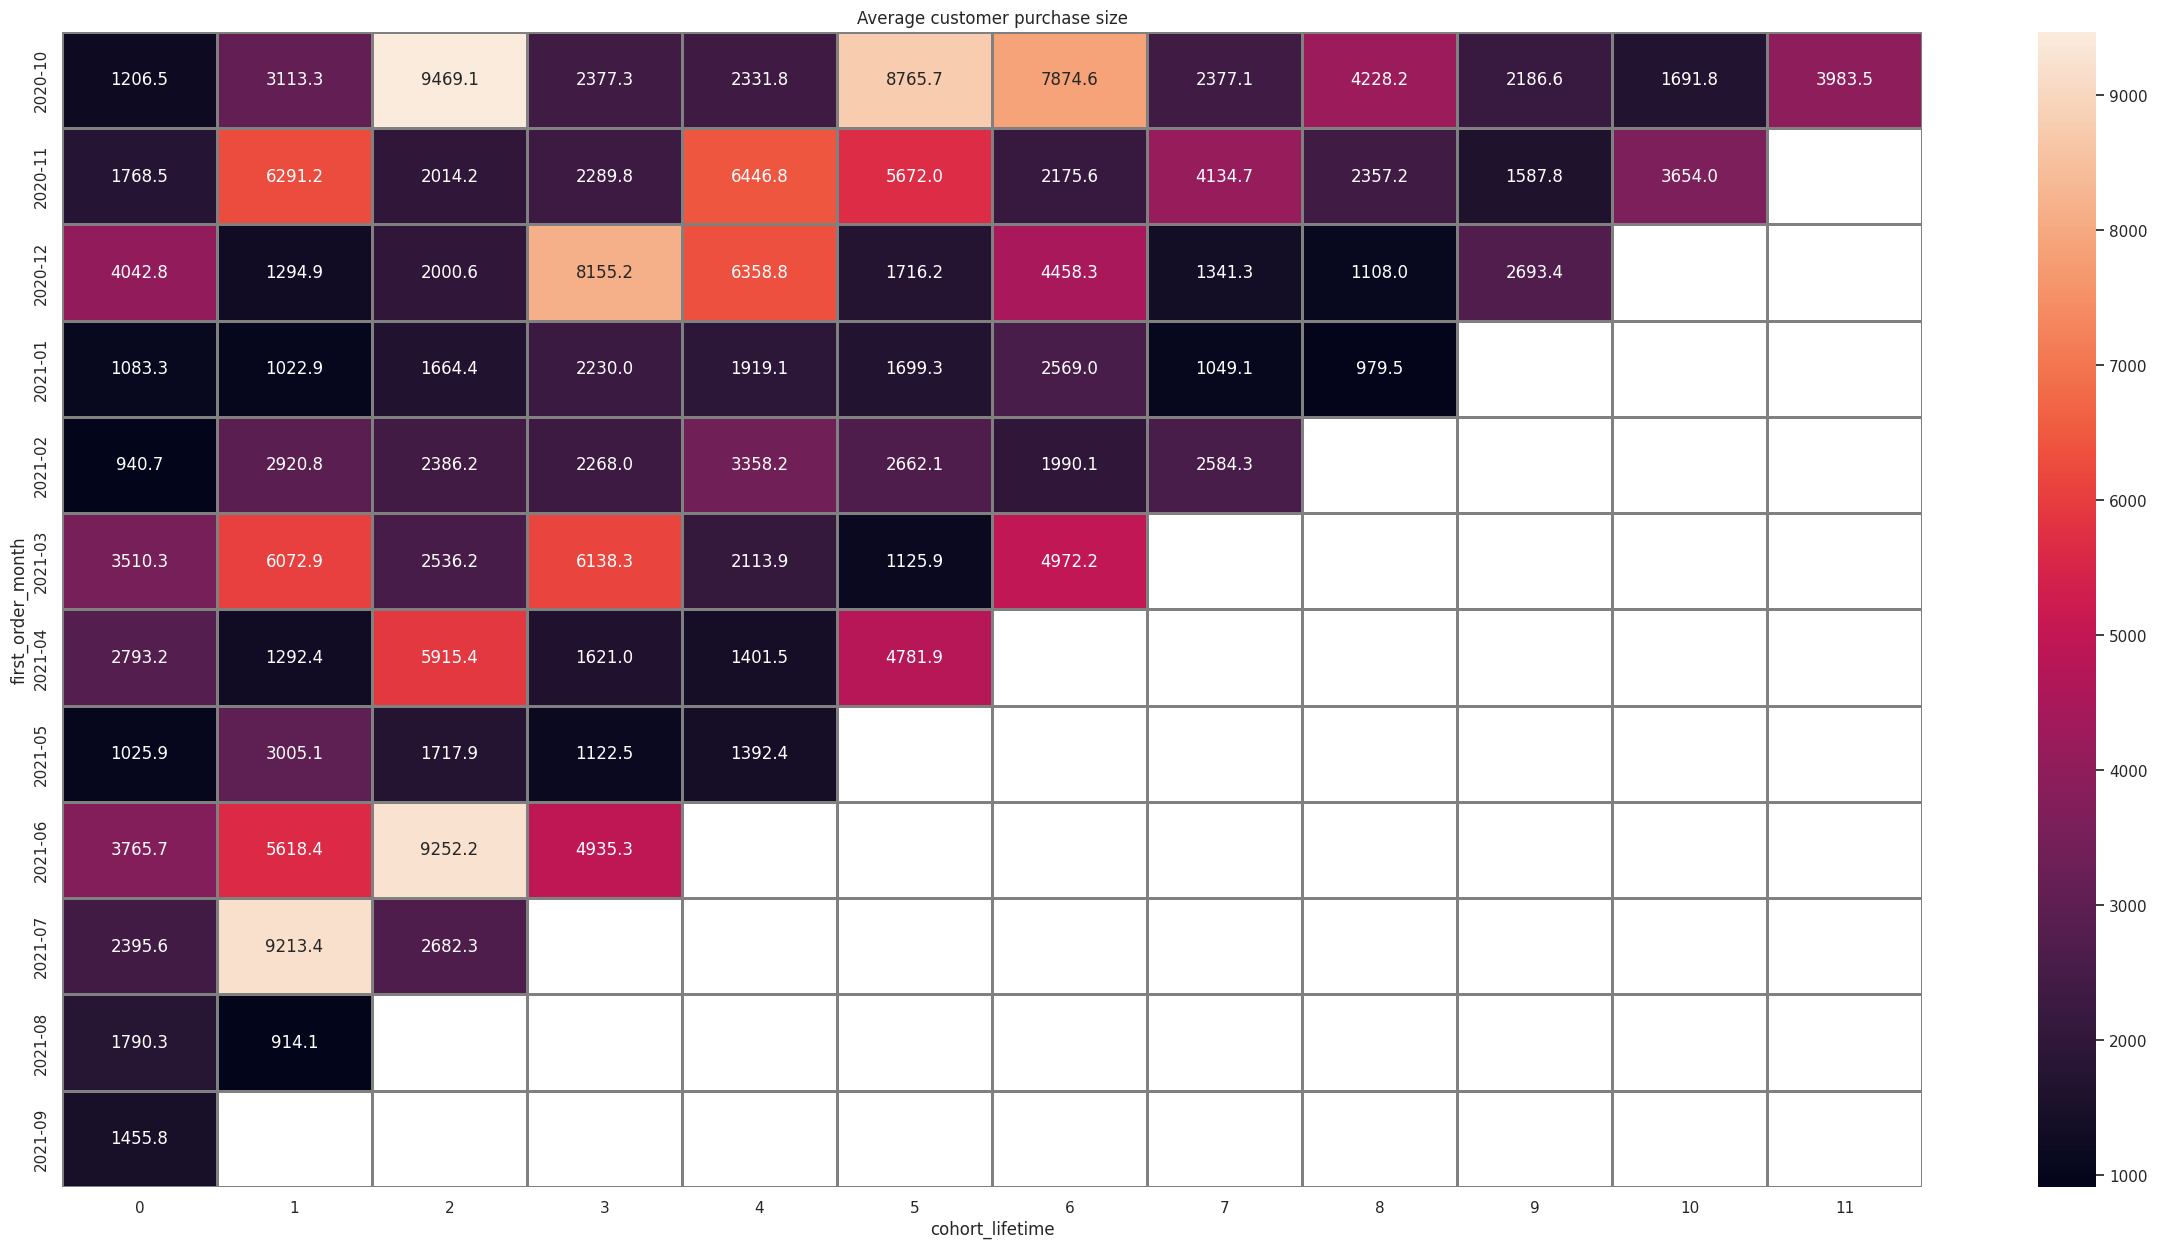

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
plt.figure(figsize=(30, 15))
plt.title('Average customer purchase size')
sns.heatmap(
    revenue_per_user_pivot,
    annot=True,
    fmt='.1f',
    linewidths=1,
    linecolor='gray',
);

* Heatmapa görə əsas müşahidələr:
1. 0 lifetime ən sabit dövrdür.
2. Heatmap-da diaqonal boyunca görünən yüksək ARPU xanaları fərqli lifetime dəyərlərinə düşsə də, hamısı 2021-03 təqvim ayına uyğun gəlir — bu daha öncə araşdırdığımız yüksək məbləğli sifarişçilərin təsiridir.


## 3. Həftəlik retention analysis

### Task 13. Həftəlik period-lar

Hər sifariş üçün sifarişin baş verdiyi həftənin başlanğıc tarixini, hər customer üçün isə ilk alış həftəsinin başlanğıc tarixini hesablayaq.


In [ ]:
orders.head()

,order_id,order_date,cust_id,full_name,status,payment_method,year,month,revenue,first_order_date,first_order_month,order_month
0,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,1887.9,2020-10-01,2020-10,2020-10
1,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,209.0,2020-10-01,2020-10,2020-10
2,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,1349.1,2020-10-01,2020-10,2020-10
3,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,719.1,2020-10-01,2020-10,2020-10
4,100367357,2020-11-13,60124,"Titus, Jani",received,cod,2020,Nov-20,199.8,2020-10-01,2020-10,2020-11


In [ ]:
orders.drop(columns=["first_order_month", "order_month"], axis=1, inplace=True)

In [ ]:
orders.head()

,order_id,order_date,cust_id,full_name,status,payment_method,year,month,revenue,first_order_date
0,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,1887.9,2020-10-01
1,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,209.0,2020-10-01
2,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,1349.1,2020-10-01
3,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,719.1,2020-10-01
4,100367357,2020-11-13,60124,"Titus, Jani",received,cod,2020,Nov-20,199.8,2020-10-01


In [ ]:
orders['order_date'].dt.weekday.head()

,order_date
0,3
1,3
2,3
3,3
4,4


In [ ]:
orders['buy_week'] = (orders['order_date']- pd.to_timedelta(orders['order_date'].dt.weekday, unit='d')).dt.normalize()

In [ ]:
orders.head()

,order_id,order_date,cust_id,full_name,status,payment_method,year,month,revenue,first_order_date,buy_week
0,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,1887.9,2020-10-01,2020-09-28
1,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,209.0,2020-10-01,2020-09-28
2,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,1349.1,2020-10-01,2020-09-28
3,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,719.1,2020-10-01,2020-09-28
4,100367357,2020-11-13,60124,"Titus, Jani",received,cod,2020,Nov-20,199.8,2020-10-01,2020-11-09


In [ ]:
orders['first_buy_week'] = (orders['first_order_date']- pd.to_timedelta(orders['first_order_date'].dt.weekday, unit='d')).dt.normalize()

In [ ]:
orders.head()

,order_id,order_date,cust_id,full_name,status,payment_method,year,month,revenue,first_order_date,buy_week,first_buy_week
0,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,1887.9,2020-10-01,2020-09-28,2020-09-28
1,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,209.0,2020-10-01,2020-09-28,2020-09-28
2,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,1349.1,2020-10-01,2020-09-28,2020-09-28
3,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,719.1,2020-10-01,2020-09-28,2020-09-28
4,100367357,2020-11-13,60124,"Titus, Jani",received,cod,2020,Nov-20,199.8,2020-10-01,2020-11-09,2020-09-28


* İlk sifariş tarixini həmin həftənin bazar ertəsinə çevirərək həftəlik kohort yaradırıq.

### Task 14. Həftəlik cohort lifetime

Hər sifarişin customer-in ilk alış həftəsindən neçə həftə sonra baş verdiyini göstərən həftəlik `cohort_lifetime` yaradaq. Bunun üçün alış həftəsindən ilk alış həftəsini çıxırıq.

In [ ]:
orders['cohort_lifetime'] = (orders['buy_week'] - orders['first_buy_week'])
orders.head()

,order_id,order_date,cust_id,full_name,status,payment_method,year,month,revenue,first_order_date,buy_week,first_buy_week,cohort_lifetime
0,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,1887.9,2020-10-01,2020-09-28,2020-09-28,0 days
1,100354678,2020-10-01,60124,"Titus, Jani",received,cod,2020,Oct-20,209.0,2020-10-01,2020-09-28,2020-09-28,0 days
2,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,1349.1,2020-10-01,2020-09-28,2020-09-28,0 days
3,100354680,2020-10-01,60124,"Titus, Jani",complete,cod,2020,Oct-20,719.1,2020-10-01,2020-09-28,2020-09-28,0 days
4,100367357,2020-11-13,60124,"Titus, Jani",received,cod,2020,Nov-20,199.8,2020-10-01,2020-11-09,2020-09-28,42 days


In [ ]:
orders['cohort_lifetime'] = orders['cohort_lifetime'] / np.timedelta64(1, 'W')
orders['cohort_lifetime'] = orders['cohort_lifetime'].astype(int)

* # Müştərinin ilk sifarişindən keçən müddəti həftələrlə ifadə edirik.

### Task 15. Həftəlik active customer-lər

Datanı ilk alış həftəsi və həftəlik `cohort_lifetime` üzrə qruplaşdıraraq hər qrup üçün unique active customer sayını hesablayaq. Bunun üçün orders cədvəlinə əsasən qruplaşdırma aparırıq.

In [ ]:
cohorts = (orders.groupby(['first_buy_week', 'cohort_lifetime']).agg({'cust_id': 'nunique'}).reset_index()
)

In [ ]:
cohorts.head()

,first_buy_week,cohort_lifetime,cust_id
0,2020-09-28,0,402
1,2020-09-28,1,26
2,2020-09-28,2,27
3,2020-09-28,3,24
4,2020-09-28,4,14


### Task 16. Initial cohort size

Hər həftəlik cohort üçün lifetime 0-dakı customer sayını müəyyən edin və bu məlumatı həftəlik cohort cədvəlinə əlavə edək.


In [ ]:
cohort_0_number = cohorts[cohorts['cohort_lifetime'] == 0][['first_buy_week', 'cust_id']]
cohort_0_number.head()

,first_buy_week,cust_id
0,2020-09-28,402
53,2020-10-05,456
105,2020-10-12,348
156,2020-10-19,406
204,2020-10-26,255


In [ ]:
cohort_0_number = cohort_0_number.rename( columns={'cust_id': 'firstweekcustomer'})

In [ ]:
cohorts = cohorts.merge(cohort_0_number, on='first_buy_week')

In [ ]:
cohorts.head()

,first_buy_week,cohort_lifetime,cust_id,firstweekcustomer
0,2020-09-28,0,402,402
1,2020-09-28,1,26,402
2,2020-09-28,2,27,402
3,2020-09-28,3,24,402
4,2020-09-28,4,14,402


### Task 17. Retention rate
Retention — müştərilərin müəyyən müddət keçdikdən sonra yenidən aktiv qalma faizidir.

Hər cohort və həftəlik lifetime üçün retention rate hesablayaq. İlk dəfə gələn müştərilərin neçə faizi sonrakı həftələrdə/aylarda geri qayıtdığını müəyyən edək.

Bunu təyin etmək üçün aktiv istifadəçi sayını lifetime 0-dakı istifadəçi sayına bölürük.

In [ ]:
cohorts['retention'] = (cohorts['cust_id'] / cohorts['firstweekcustomer'])
cohorts.head()

,first_buy_week,cohort_lifetime,cust_id,firstweekcustomer,retention
0,2020-09-28,0,402,402,1.000000
1,2020-09-28,1,26,402,0.064677
2,2020-09-28,2,27,402,0.067164
3,2020-09-28,3,24,402,0.059701
4,2020-09-28,4,14,402,0.034826


### Task 18. Retention matrix və heatmap

Həftəlik retention nəticəsini pivot table formasına çevirək və faiz formatında heatmap hazırlayaq.
Sətirlərdə ilk alış həftəsi,sütunlarda kohort lifetime, ortalama gəliri hesablayaq.

In [ ]:
retention_pivot = cohorts.pivot_table(index='first_buy_week',columns='cohort_lifetime', values='retention',  aggfunc='mean')

In [ ]:
retention_pivot.head()

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
first_buy_week,,,,,,,,,,,,,,,,,,,,,
2020-09-28,1.0,0.064677,0.067164,0.059701,0.034826,0.052239,0.079602,0.067164,0.049751,0.039801,...,0.022388,0.014925,0.007463,0.009950,0.007463,0.007463,0.017413,0.037313,0.002488,0.004975
2020-10-05,1.0,0.085526,0.063596,0.037281,0.054825,0.043860,0.050439,0.050439,0.037281,0.043860,...,0.015351,0.006579,0.004386,0.006579,0.004386,0.008772,0.017544,0.010965,0.004386,NaN
2020-10-12,1.0,0.109195,0.060345,0.086207,0.080460,0.048851,0.051724,0.051724,0.086207,0.129310,...,0.017241,0.002874,0.011494,0.002874,0.017241,0.057471,0.005747,0.008621,NaN,NaN
2020-10-19,1.0,0.059113,0.078818,0.061576,0.036946,0.041872,0.039409,0.036946,0.078818,0.096059,...,0.002463,0.012315,0.012315,0.017241,0.019704,0.002463,0.007389,NaN,NaN,NaN
2020-10-26,1.0,0.117647,0.086275,0.066667,0.078431,0.050980,0.070588,0.113725,0.137255,0.062745,...,0.003922,0.007843,0.011765,0.027451,0.007843,NaN,NaN,NaN,NaN,NaN


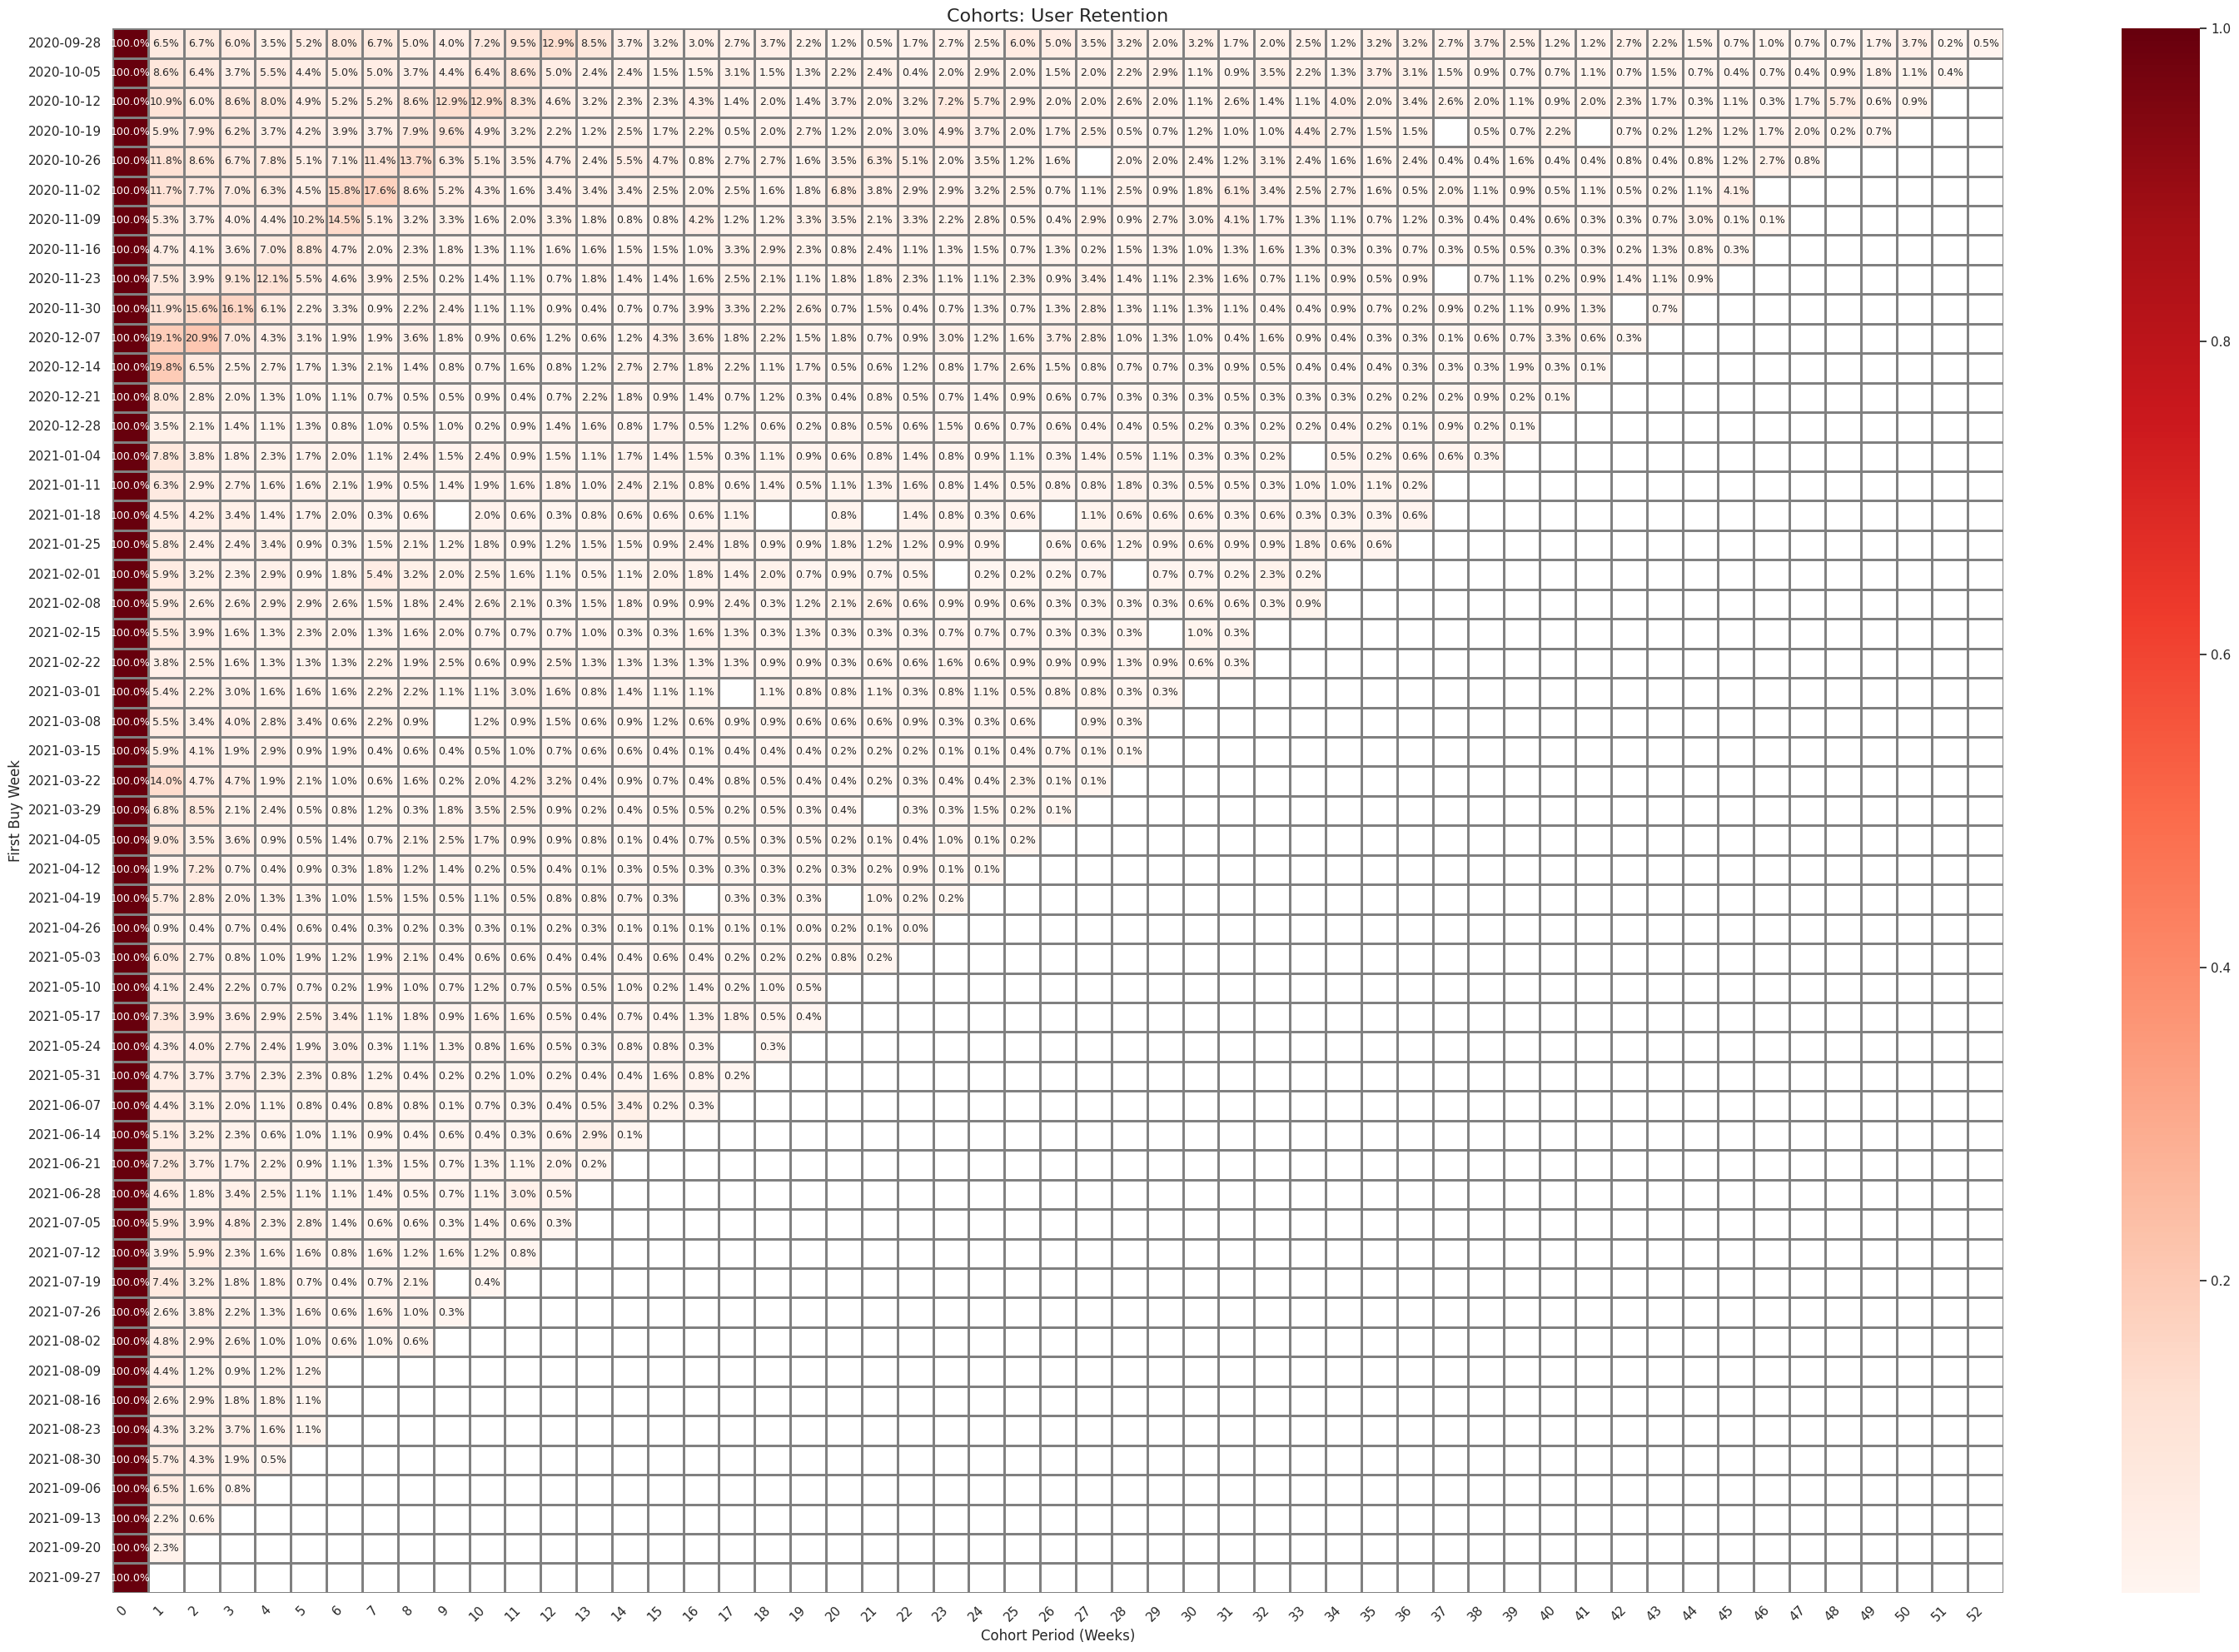

In [ ]:
retention_pivot.index = pd.to_datetime(retention_pivot.index).strftime('%Y-%m-%d')
sns.set(style='white')
plt.figure(figsize=(30, 20))
plt.title('Cohorts: User Retention', fontsize=16)


sns.heatmap(retention_pivot,
    annot=True,
    fmt='.1%',
    linewidths=1,
    linecolor='gray',
    cmap='Reds',
    annot_kws={"size": 9}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.ylabel('First Buy Week')
plt.xlabel('Cohort Period (Weeks)')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px


retention_pivot.index = pd.to_datetime(retention_pivot.index)

retention_pivot.index = retention_pivot.index.strftime('%Y-%m-%d')
retention_pivot.columns = retention_pivot.columns.astype(str)

fig = px.imshow(
    retention_pivot.values,
    x=retention_pivot.columns,
    y=retention_pivot.index,
    labels={
        "x": "Cohort Period (Lifetime)",
        "y": "First Buy Week",
        "color": "Retention"
    },
    color_continuous_scale="Reds",
    text_auto=".1%",
    aspect="auto"
)


fig.update_yaxes(type='category')

fig.update_layout(
    title="Cohorts: User Retention",
    width=2000,
    height=950
)
fig.show()


* İlk aktiv həftədən sonra retention 90%+-dən çox azalır (adətən 2-9% aralığına düşür) — bu, birinci-alış müştərilərinin əksəriyyətinin bir-dəfəlik alıcı olduğunu göstərir.
* 2020-12-07/14 həftələrindəki cohort-lar digərlərindən qat-qat yüksək retention göstərir (15-25% aralığında, adi səviyyə isə 1-5%-dir). Bu, əvvəlki analizdə aşkarlanan dekabr 2020 kampaniyasının/pikinin təbii nəticəsidir
* Retention matrisi göstərir ki, müştərilərin böyük əksəriyyəti ilk alışdan sonra 1-ci həftədə itirilir (retention adətən 2-9%-ə düşür), bu da güclü bir 'ilk təəssürat/ilk təkrar alış' probleminin olduğunu göstərir. 2020-12 həftələrində görünən qeyri-adi yüksək retention (15-25%) dekabr ayındakı böyük həcmli kampaniya ilə bağlı ola bilər və ayrıca araşdırma tələb edir.

### Task 19. Churn rate

Churn Rate — müəyyən müddət ərzində müştərilərdən neçəsinin itirildiyini, yəni artıq aktiv olmadığını göstərən faizdir.

Sadə formula:

Churn Rate = (İtirilən müştərilər / Dövrün əvvəlindəki müştərilər) × 100

In [ ]:
churn_pivot = 1 - retention_pivot

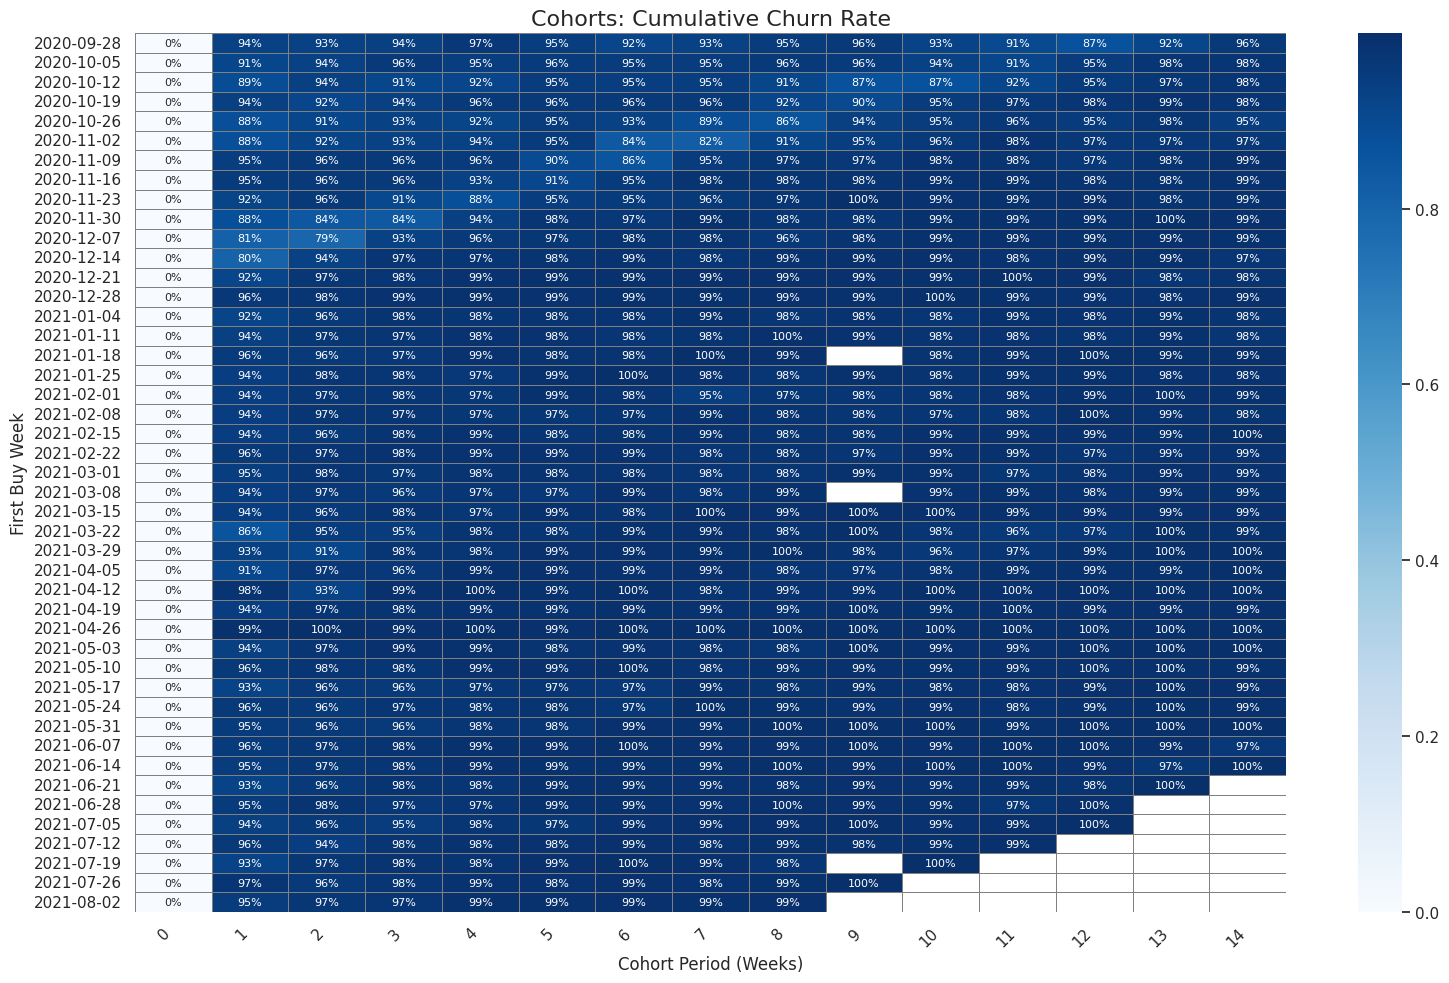

In [ ]:


# Oxunaqlılıq üçün yalnız ilk 15 lifetime dövrünü götürürük
churn_pivot_display = churn_pivot.iloc[:-8, :15]

sns.set(style='white')
plt.figure(figsize=(16, 10))
plt.title('Cohorts: Cumulative Churn Rate', fontsize=16)

sns.heatmap(
    churn_pivot_display,
    annot=True,
    fmt='.0%',
    linewidths=0.5,
    linecolor='gray',
    cmap='Blues',
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.ylabel('First Buy Week')
plt.xlabel('Cohort Period (Weeks)')
plt.tight_layout()
plt.show()

* Churn rate lifetime artdıqca sürətlə 100%-ə yaxınlaşır, bu da göstərir ki, cohort-ların böyük əksəriyyəti bir neçə həftə ərzində tamamilə passivləşir. Bu, uzunmüddətli müştəri loyallığı proqramlarının zəruriliyini göstərir."

## 4. Yekun nəticələr

### Task 20. Nəticələrin şərhi

1. Aylıq trend və 2020-12 anomaliyası
Aylıq cohort göstəriciləri il boyu sabit artımdan çox, kəskin dalğalanmalar nümayiş etdirir. 2020-dekabr ayı bütün göstəricilərdə (sifariş, müştəri, gəlir) digər aylardan 9-20 dəfə yüksəkdir — gündəlik paylanma araşdırıldıqda bunun ayın 20-30-u arasında baş verən il-sonu kampaniyası/bayram tələbatı ilə bağlı olduğu müəyyən edildi. Maraqlıdır ki, 2021-dekabrda bənzər artım yoxdur, çünki bu ay üçün data yalnız ayın 9-na qədər mövcuddur — deməli 2021-12 datası natamamdır və müqayisəyə yararsızdır.

2. ARPU sabitdir, amma outlier-lər var
Yeni müştərinin ilk aydakı orta xərci (lifetime=0 ARPU) bütün cohort-larda 650-2000 aralığında sabit qalıb. Lakin 2021-03 təqvim ayında bütün cohort-larda ARPU qeyri-adi yüksəkdir (10K-14K). Araşdırma göstərdi ki, bu kampaniya effekti deyil — bir neçə müştərinin (70K-187K aralığında) həddindən artıq böyük tək sifarişi orta göstəricini təhrif edib.

3. Retention çox aşağıdır — "bir-dəfəlik alıcı" problemi üstünlük təşkil edir
İlk aktiv həftədən sonra retention 90%+ azalır (adətən 2-9%-ə düşür). Bu, müştərilərin əksəriyyətinin təkrar alış etmədiyini göstərir. 2020-12 həftələrində retention nisbətən yüksəkdir (15-25%), lakin bu da yenə həmin ayın anomal həcmi ilə əlaqəlidir.

4. Churn sürətlə 100%-ə yaxınlaşır
churn hesablaması göstərir ki, cohort-ların böyük əksəriyyəti bir neçə həftə ərzində demək olar ki, tamamilə passivləşir.

Biznes tövsiyələri
1. Retention proqramına təcili ehtiyac var. İlk həftədən sonrakı 90%+ itki səviyyəsi kritikdir. İlk alışdan sonra 3-7 gün ərzində email/push ilə təkrar-alış kampaniyası (endirim kuponu, "sizə uyğun məhsullar" tövsiyəsi) tətbiq edilməlidir.

2. 2020-12 kampaniyasının uğur modeli təkrarlanmalıdır

3. Data keyfiyyəti nəzarəti təmin edilməlidir — 2021-12-nin natamam olması göstərir ki, hesabat dövrləri üçün data tamlığı yoxlanılmalı, əks halda son ayların göstəriciləri səhv trend kimi şərh oluna bilər.

<!-- Cavabınızı burada yazın. -->